Imports

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [173]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [174]:
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
from fairlearn.postprocessing import ThresholdOptimizer

In [175]:
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

Load dataset

In [176]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

In [177]:
df_train = pd.read_csv('../data/adult.data', header=None, names=columns, na_values=['?', ' ?', '? '], skipinitialspace=True)

In [178]:
df_test = pd.read_csv('../data/adult.test', header=None, names=columns, na_values=['?', ' ?', '? '], skipinitialspace=True, skiprows=1)

In [179]:
df_train['is_test'] = 0
df_test['is_test'] = 1
df = pd.concat([df_train, df_test], ignore_index=True)

In [180]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       46043 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      46033 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  47985 non-null  str  
 14  income          48842 non-null  str  
 15  is_test         48842 non-null  int64
dtypes: int64(7), str(9)
memory usage: 6.0 MB


In [136]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,is_test
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


Convert text columns to 'category' dtype (without income)

In [181]:
string_columns = df.select_dtypes(include=['object', 'string', 'str']).columns
string_columns = string_columns.drop('income', errors='ignore')

In [182]:
for col in string_columns:
    df[col] = df[col].astype('category')

Convert Y from <=50K and >50K to numeric 0 and 1

In [183]:
df['income'] = df['income'].astype(str).str.replace('.', '', regex=False).str.strip()
df['income'] = df['income'].str.strip().apply(lambda x: 1 if x == '>50K' else 0)
df['income'] = df['income'].astype('int8')

Downscaling of numeric columns

In [184]:
int_columns = df.select_dtypes(include=['int64']).columns
for col in int_columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

Check new dtypes

In [185]:
df.dtypes

age                   int8
workclass         category
fnlwgt               int32
education         category
education-num         int8
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int32
capital-loss         int16
hours-per-week        int8
native-country    category
income                int8
is_test               int8
dtype: object

In [142]:
# check number of train and test samples
print(f"Train samples: {df[df['is_test'] == 0].shape[0]}")
print(f"Test samples: {df[df['is_test'] == 1].shape[0]}")  

Train samples: 32561
Test samples: 16281


# EDA 

### Target Variable Distribution

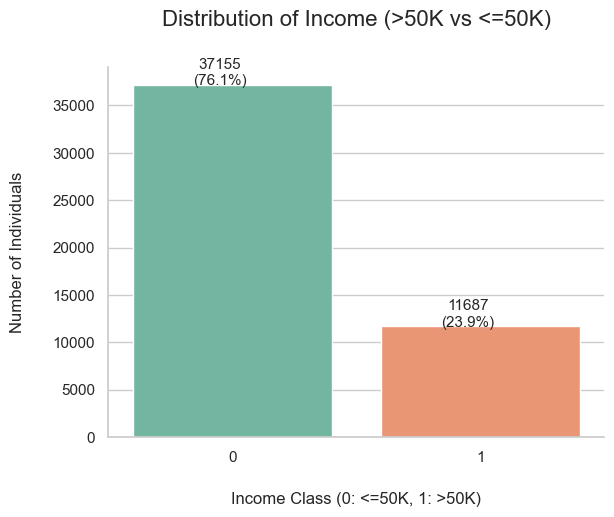

In [201]:
ax = sns.countplot(x='income', data=df, hue='income', legend=False, palette='Set2')
plt.title('Distribution of Income (>50K vs <=50K)', fontsize=16, pad=30)
plt.xlabel('Income Class (0: <=50K, 1: >50K)', fontsize=12, labelpad=20)
plt.ylabel('Number of Individuals', fontsize=12, labelpad=20)
total = len(df['income'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() # lekki offset nad słupkiem
    ax.annotate(f'{int(p.get_height())}\n({percentage})', (x, y), ha='center', fontsize=11)

sns.despine()
plt.show()

## Sensitive data distribution
- race 
- gender

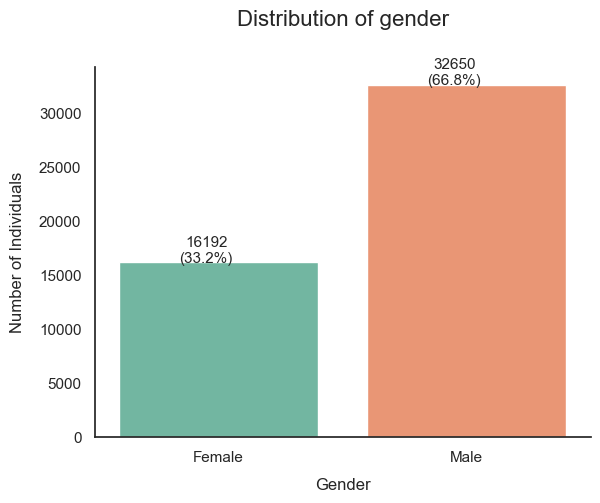

In [217]:
ax = sns.countplot(x='sex', data=df, hue='sex', legend=False, palette='Set2', dodge=False)
plt.title('Distribution of gender', fontsize=16, pad=30)
plt.xlabel('Gender', fontsize=12, labelpad=10)
plt.ylabel('Number of Individuals', fontsize=12, labelpad=10)
total = len(df['sex'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() 
    ax.annotate(f'{int(p.get_height())}\n({percentage})', (x, y), ha='center', fontsize=11)

sns.despine()
plt.show()

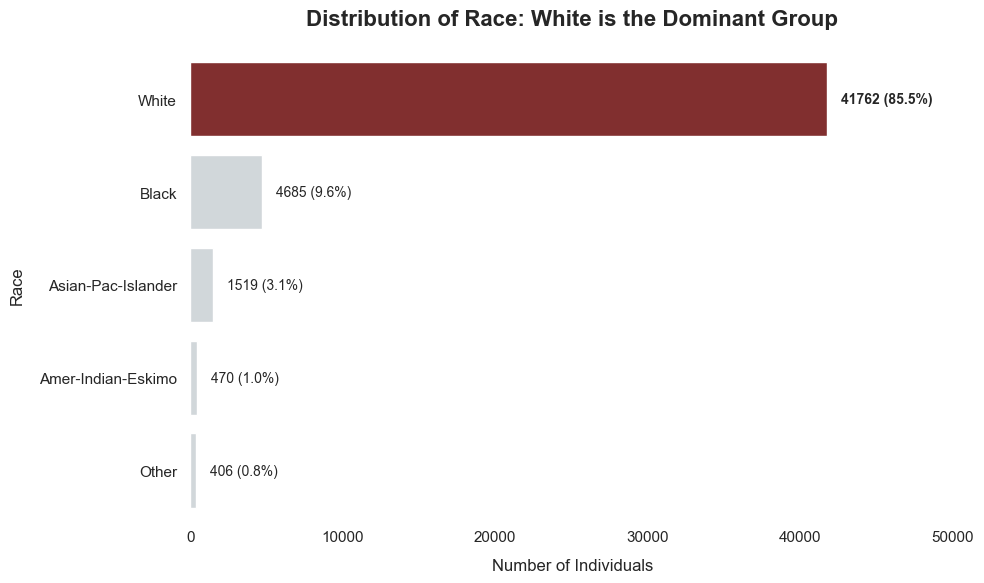

In [225]:

order = df['race'].value_counts().index
n_categories = len(order)

# 2. Stworzenie customowej palety
# Pierwszy kolor to np. 'steelblue' lub 'salmon', reszta to jasny szary
colors = ['#CFD8DC'] * (n_categories - 1) + ["#8F2121"] 

plt.figure(figsize=(10, 6))

# 3. Przekazujemy naszą paletę do countplot
ax = sns.countplot(
    y='race', 
    data=df, 
    order=order, 
    hue='race', 
    dodge=False, 
    legend=False, 
    palette=colors # <--- Używamy zdefiniowanej listy kolorów
)

plt.title('Distribution of Race: White is the Dominant Group', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Number of Individuals', fontsize=12, labelpad=10)
plt.ylabel('Race', fontsize=12, labelpad=10)

# Reszta kodu adnotacji pozostaje bez zmian
total = len(df['race'])
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        percentage = f'{(100 * width / total):.1f}%'
        ax.annotate(
            f'{int(width)} ({percentage})', 
            (width, p.get_y() + p.get_height() / 2), 
            va='center', 
            xytext=(10, 0), 
            textcoords='offset points',
            fontsize=10,
            # Dobra praktyka: pogrubiamy tylko tekst przy wyróżnionym słupku
            fontweight='bold' if width == df['race'].value_counts().max() else 'normal'
        )

# Zwiększamy limit osi X, aby napisy się zmieściły
ax.set_xlim(0, df['race'].value_counts().max() * 1.2)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Numerical Feature Analysis

In [171]:
# df.hist(figsize=(12,8))

Boxplots by income

In [202]:
# sns.boxplot(x='income', y='age', data=df)

Correlation matrix

In [203]:
# sns.heatmap(df.corr(numeric_only=True), annot=True)

Countplots

In [204]:
# sns.countplot(y='occupation', data=df).set_title('Occupation Distribution')

In [148]:
df.groupby('education')['income'].mean().sort_values(ascending=False)

education
Prof-school     0.739808
Doctorate       0.725589
Masters         0.549116
Bachelors       0.412835
Assoc-acdm      0.257964
Assoc-voc       0.253275
Some-college    0.189649
HS-grad         0.158578
12th            0.073059
7th-8th         0.064921
10th            0.062635
9th             0.054233
5th-6th         0.053045
11th            0.050773
1st-4th         0.032389
Preschool       0.012048
Name: income, dtype: float64

## Propabilities of earning >=50K in subgroups
- gender 
- race 

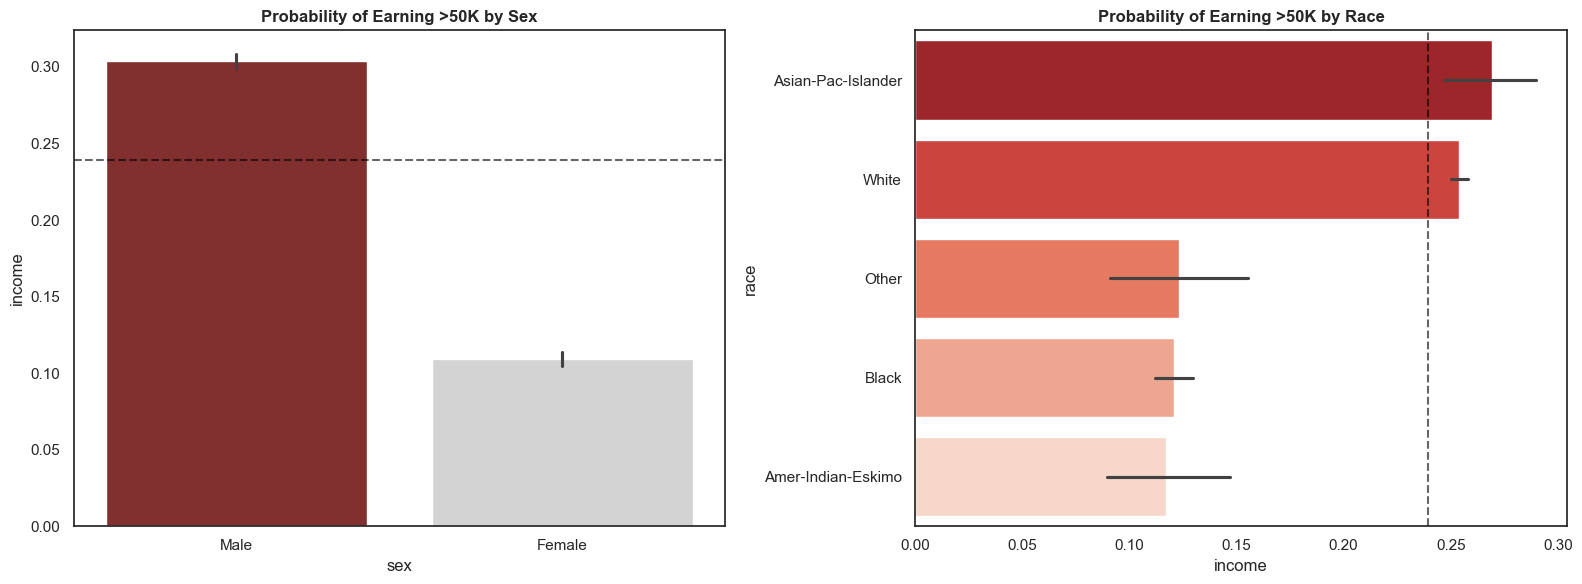

In [226]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Wykres dla Płci
sns.barplot(x='sex', y='income', data=df, ax=ax1, palette=['#8F2121', '#D3D3D3'], 
            order=df.groupby('sex')['income'].mean().sort_values(ascending=False).index)
ax1.axhline(df['income'].mean(), color='black', linestyle='--', alpha=0.6)
ax1.set_title('Probability of Earning >50K by Sex', fontweight='bold')

# Wykres dla Rasy
sns.barplot(x='income', y='race', data=df, ax=ax2, palette='Reds_r',
            order=df.groupby('race')['income'].mean().sort_values(ascending=False).index)
ax2.axvline(df['income'].mean(), color='black', linestyle='--', alpha=0.6)
ax2.set_title('Probability of Earning >50K by Race', fontweight='bold')

plt.tight_layout()
plt.show()

## Propabilities of earning >=50K - Intersectionality of race and gender

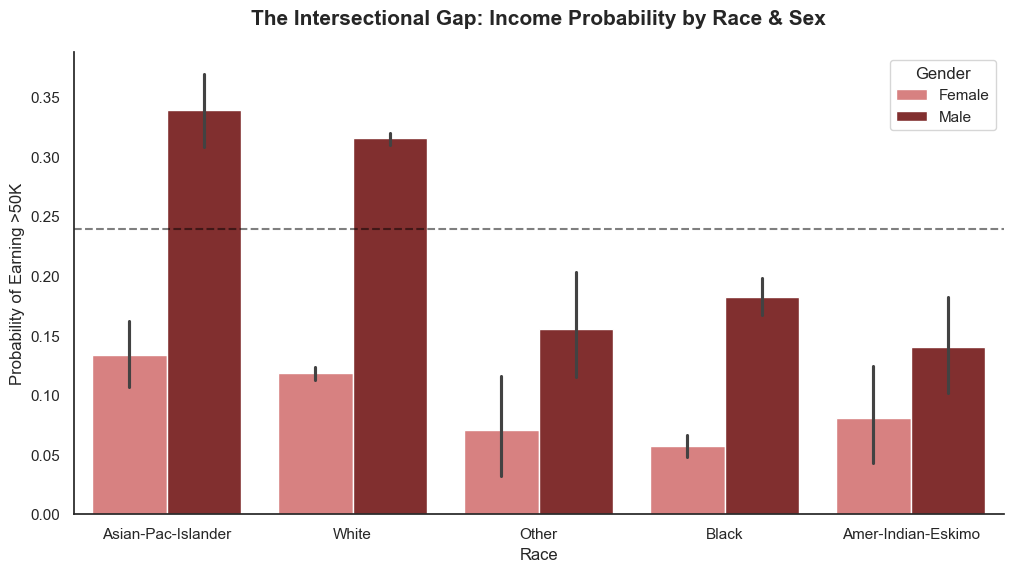

In [227]:
plt.figure(figsize=(12, 6))

# Porządkujemy rasy według średniego dochodu dla spójności
race_order = df.groupby('race')['income'].mean().sort_values(ascending=False).index

sns.barplot(x='race', y='income', hue='sex', data=df, 
            order=race_order, palette={'Male': '#8F2121', 'Female': '#E57373'})

plt.axhline(df['income'].mean(), color='black', linestyle='--', alpha=0.5)
plt.title('The Intersectional Gap: Income Probability by Race & Sex', fontsize=15, pad=20, fontweight='bold')
plt.ylabel('Probability of Earning >50K')
plt.xlabel('Race')
plt.legend(title='Gender')
sns.despine()
plt.show()

## Proxy variables

How much relationship column is showing gender:

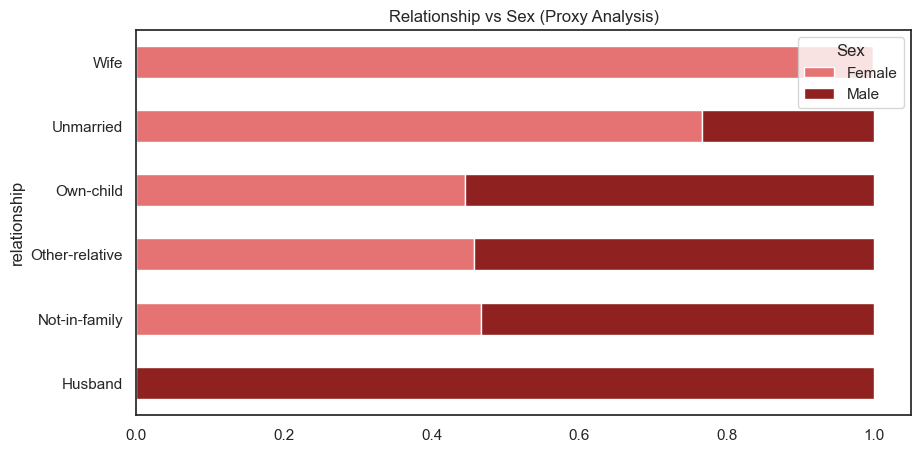

In [ ]:
pd.crosstab(df['relationship'], df['sex'], normalize='index').plot(
    kind='barh', stacked=True, color=['#E57373', '#8F2121'], figsize=(10, 5)
)
plt.title('Relationship vs Sex (Proxy Analysis)')
plt.legend(title='Sex', loc='upper right')
plt.show()

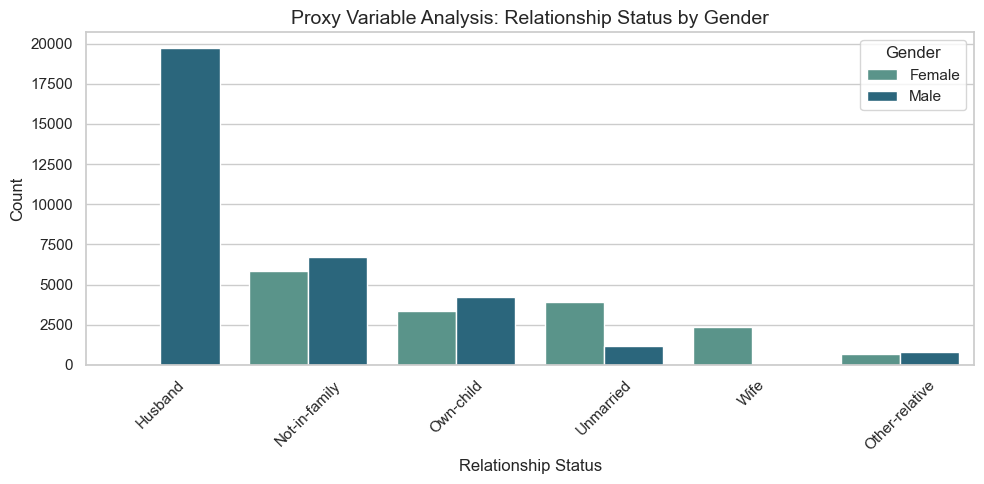

In [151]:
plt.figure(figsize=(10, 5))

order = df['relationship'].value_counts().index

sns.countplot(
    data=df,
    x='relationship',
    hue='sex',
    order=order,
    palette='crest'
)

plt.title('Proxy Variable Analysis: Relationship Status by Gender', fontsize=14)
plt.xlabel('Relationship Status')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.legend(title='Gender')

plt.tight_layout()
plt.show()

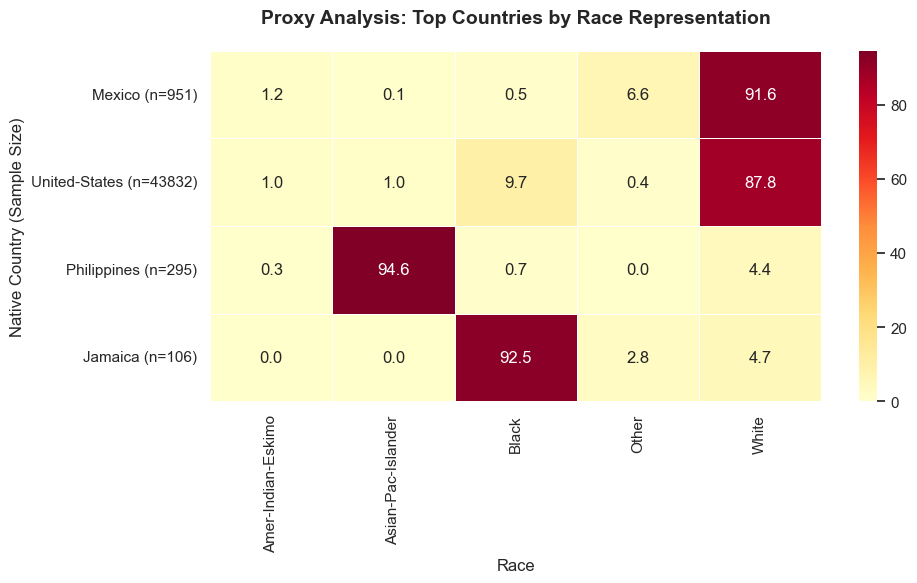

In [229]:
# 1. Znajdujemy kraje z największą liczbą osób dla konkretnych grup (poza USA)
top_black = df[df['race'] == 'Black']['native-country'].value_counts().head(2).index.tolist()
top_asian = df[df['race'] == 'Asian-Pac-Islander']['native-country'].value_counts().head(2).index.tolist()
top_white = ['United-States', 'Germany'] # USA jako baza + inny kraj z dużą liczbą White

# Łączymy w jedną listę unikalnych krajów
selected_countries = list(set(['United-States'] + top_black + top_asian + ['Mexico']))

# 2. Tworzymy subset z liczebnością (n=...) w nazwie osi
proxy_race = pd.crosstab(df['native-country'], df['race'], normalize='index') * 100
counts = df['native-country'].value_counts()

subset = proxy_race.loc[selected_countries].fillna(0)
new_labels = [f"{c} (n={counts[c]})" for c in subset.index]

# 3. Wykres
plt.figure(figsize=(10, 6))
sns.heatmap(subset, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=.5)

plt.title("Proxy Analysis: Top Countries by Race Representation", fontsize=14, fontweight="bold", pad=20)
plt.ylabel("Native Country (Sample Size)")
plt.xlabel("Race")
plt.yticks(ticks=np.arange(len(new_labels)) + 0.5, labels=new_labels, rotation=0)

plt.tight_layout()
plt.show()

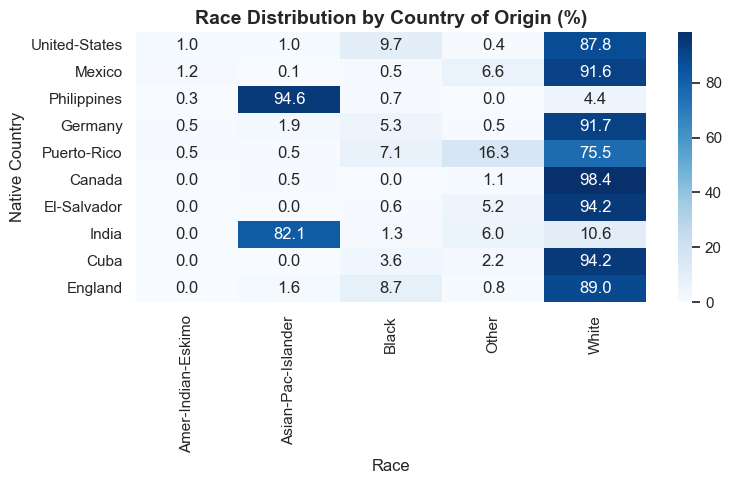

In [163]:
top_countries = df['native-country'].value_counts().head(10).index

proxy_race = pd.crosstab(
    df['native-country'],
    df['race'],
    normalize='index'
) * 100

subset = proxy_race.loc[top_countries]
plt.figure(figsize=(8, 5))

sns.heatmap(
    subset,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Race Distribution by Country of Origin (%)", fontsize=14, fontweight="bold")
plt.xlabel("Race")
plt.ylabel("Native Country")

plt.tight_layout()
plt.show()

___________________

In [230]:
df.dtypes

age                   int8
workclass         category
fnlwgt               int32
education         category
education-num         int8
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int32
capital-loss         int16
hours-per-week        int8
native-country    category
income                int8
is_test               int8
dtype: object

# Baseline model
- logistic regression
- random forest 

Performance is calculated based on:
- accuracy, 
- precision,
- recall,
- f1-score

Fairness is calculated based on:
- demographic parity difference (DPD) -> differences in frequentility of predicting class 1 between different groups (man vs woman, in between different races)
- Equalized Odds Difference (EOD) -> does the model makes mistakes in both groups? takes into account TPR, FPR

In [232]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference, equalized_odds_difference


def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fp / (fp + tn)

def run_baseline_model(df, sensitive_col='sex', target_col='income'):
    train_df = df[df['is_test'] == 0].copy()
    test_df = df[df['is_test'] == 1].copy()

    y_train = train_df[target_col]
    y_test = test_df[target_col]

    # Zmienne wejściowe (usuwamy target i znacznik testu)
    X_train = train_df.drop(columns=[target_col, 'is_test'])
    X_test = test_df.drop(columns=[target_col, 'is_test'])

    # Automatyczna selekcja cech na podstawie typów danych
    numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
    categorical_features = X_train.select_dtypes(include=['category']).columns.tolist()

    # Pipeline Przetwarzania (Preprocessing)
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), numeric_features),
            ('cat', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ]), categorical_features)
        ])

    # Pipeline Modelu
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ])

    # Trening i Predykcja
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Definicja metryk do analizy podgrup
    metrics_dict = {
        'Accuracy': accuracy_score,
        'Precision': precision_score,
        'Recall (TPR)': recall_score,
        'FPR': false_positive_rate,      
        'F1-Score': f1_score,
        'Selection Rate': selection_rate 
    }

    mf = MetricFrame(
        metrics=metrics_dict,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=test_df[sensitive_col]
    )

    fairness_results = {
        'DPD': demographic_parity_difference(y_test, y_pred, sensitive_features=test_df[sensitive_col]),
        'EOD': equalized_odds_difference(y_test, y_pred, sensitive_features=test_df[sensitive_col])
    }

    return mf, fairness_results


metrics_sex, fairness_sex = run_baseline_model(df, sensitive_col='sex')
metrics_race, fairness_race = run_baseline_model(df, sensitive_col='race')

# comparison of performance

,Accuracy,Precision,Recall (TPR),FPR,F1-Score,Selection Rate
Baseline (Random Forest),0.850869,0.717085,0.608944,0.074306,0.658605,0.200602


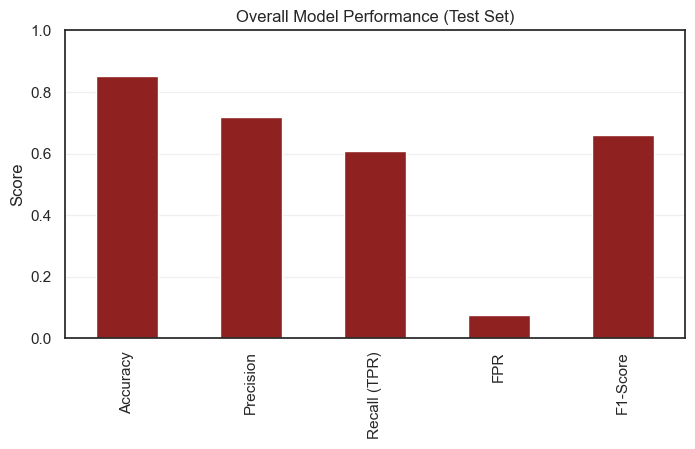

In [240]:
overall_metrics = pd.DataFrame(metrics_sex.overall).rename(columns={0: 'Baseline (Random Forest)'})

display(overall_metrics.T)

overall_metrics.drop('Selection Rate', axis=0).plot(kind='bar', figsize=(8, 4), color='#8F2121', legend=False)
plt.title('Overall Model Performance (Test Set)')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.3)
plt.show()

Wnioski:
- Accuracy (0.85): Model poprawnie klasyfikuje około 85% wszystkich przypadków -- dobry wynik
- Precision (0.72): Kiedy model przewiduje, że dana osoba zarabia powyżej 50K, ma rację w 72% przypadków. Pozostałe 28% to osoby sklasyfikowane błędnie jako zamożne.
- Recall / TPR (0.61): Model wykrywa 61% wszystkich osób, które faktycznie zarabiają powyżej 50K. Oznacza to, że niemal 40% osób o wysokich zarobkach jest przez model "pomijanych" (False Negatives).
- FPR (0.07): Tylko 7% osób zarabiających mało zostaje błędnie uznanych za osoby zamożne. Model jest więc dość "ostrożny" w przyznawaniu wysokich zarobków.
- Selection Rate (0.20): Model przewiduje wysokie zarobki dla około 20% całej populacji testowej.


In [236]:
fairness_sex

{'DPD': np.float64(0.17435382760514923), 'EOD': 0.07683217202246015}

In [233]:
fairness_summary = pd.DataFrame({
    'Metric': ['DPD (Demographic Parity)', 'EOD (Equalized Odds)'],
    'Sex': [fairness_sex['DPD'], fairness_sex['EOD']],
    'Race': [fairness_race['DPD'], fairness_race['EOD']]
})
print("--- Fairness Baseline Summary ---")
display(fairness_summary)

--- Fairness Baseline Summary ---


,Metric,Sex,Race
0,DPD (Demographic Parity),0.174354,0.185024
1,EOD (Equalized Odds),0.076832,0.338346


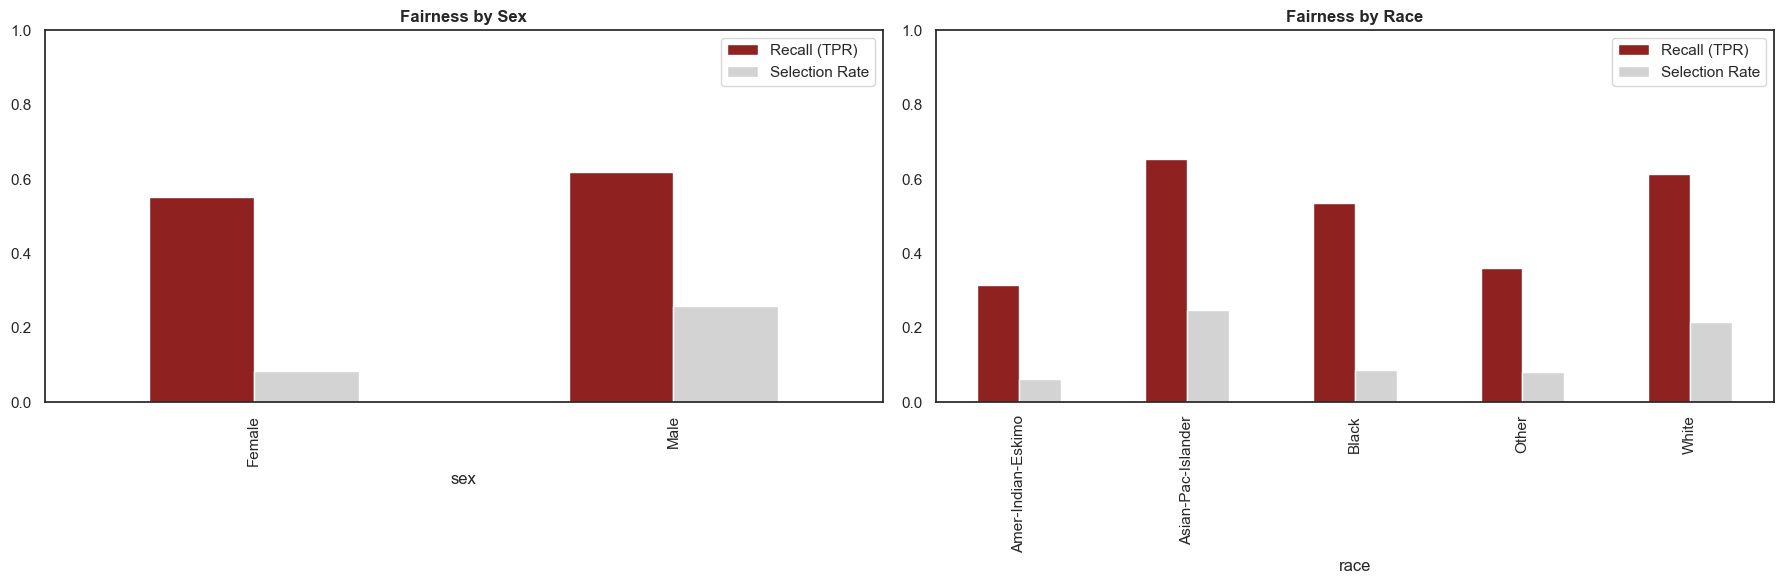

In [234]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

metrics_sex.by_group[['Recall (TPR)', 'Selection Rate']].plot(kind='bar', ax=ax1, color=['#8F2121', '#D3D3D3'])
ax1.set_title('Fairness by Sex', fontweight='bold')
ax1.set_ylim(0, 1)

metrics_race.by_group[['Recall (TPR)', 'Selection Rate']].plot(kind='bar', ax=ax2, color=['#8F2121', '#D3D3D3'])
ax2.set_title('Fairness by Race', fontweight='bold')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Fairness overall Metrics - for baseline model

,DPD,EOD
Sex,0.174354,0.076832
Race,0.185024,0.338346


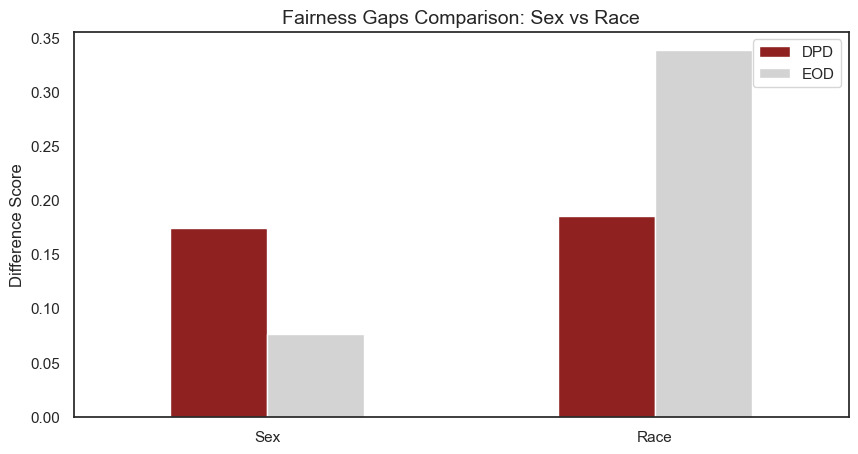

In [244]:
fairness_df = pd.DataFrame({
    'Sex': fairness_sex,
    'Race': fairness_race
}).T

display(fairness_df)

fairness_df.plot(kind='bar', figsize=(10, 5), color=['#8F2121', '#D3D3D3'])
plt.title('Fairness Gaps Comparison: Sex vs Race', fontsize=14)
# plt.axhline(y=0.1, color='gray', linestyle='--', label='10% Threshold') 
plt.ylabel('Difference Score')
plt.xticks(rotation=0)
plt.legend()
plt.show()

Wnioski:
- DPD (Demographic Parity Difference):

Sex (0.174): Istnieje 17,4% różnicy w częstotliwości przewidywania wysokich zarobków między kobietami a mężczyznami. Jeśli np. 25% mężczyzn otrzymuje predykcję ">50K", to u kobiet jest to tylko ok. 7,6%.

Race (0.185): Różnica między grupą z najwyższym a najniższym wskaźnikiem selekcji wynosi 18,5%.

Wniosek: Obie cechy wykazują zbliżony, wysoki poziom braku równości demograficznej.

- EOD (Equalized Odds Difference):

Sex (0.077): Różnica w trafności (TPR lub FPR) wynosi około 8%.

Race (0.338): To jest krytyczny punkt. Wynik 33,8% oznacza ogromną dysproporcję. Model drastycznie lepiej rozpoznaje osoby zamożne w jednej grupie rasowej niż w innej (lub drastycznie częściej myli się na korzyść jednej z nich).

# Precise subgroup analysis

Recall (TPR), FPR oraz Selection Rate.

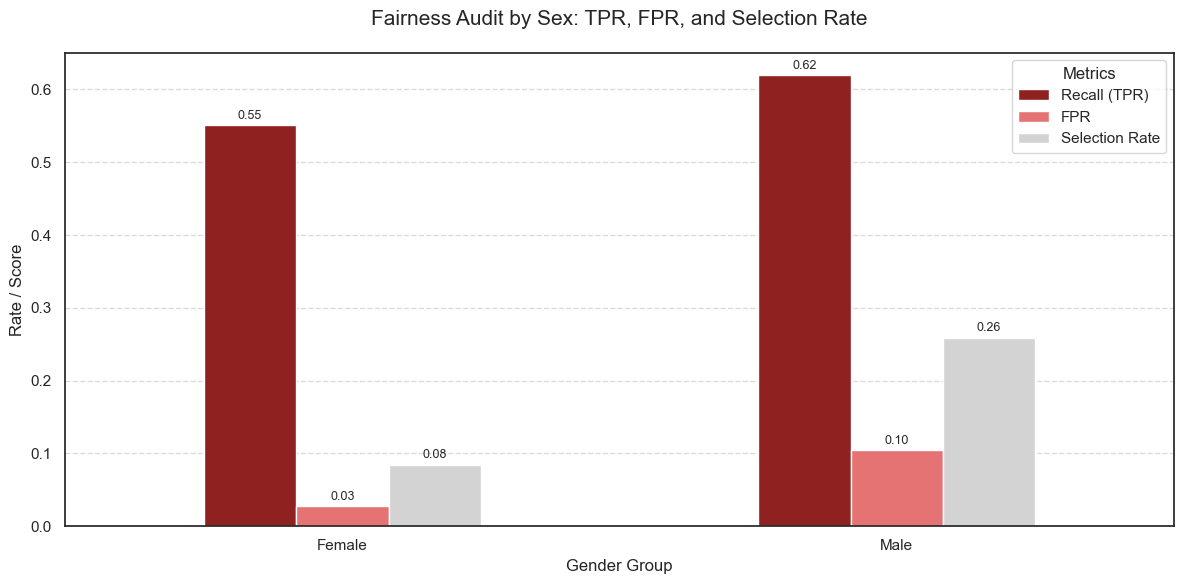

In [245]:

ax = metrics_sex.by_group[['Recall (TPR)', 'FPR', 'Selection Rate']].plot(
    kind='bar', 
    figsize=(12, 6), 
    color=['#8F2121', '#E57373', '#D3D3D3'],
    rot=0
)

plt.title('Fairness Audit by Sex: TPR, FPR, and Selection Rate', fontsize=15, pad=20)
plt.ylabel('Rate / Score')
plt.xlabel('Gender Group')
plt.legend(title='Metrics', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

- Selection Rate
Model przewiduje wysokie zarobki dla 26% mężczyzn i tylko 8% kobiet.

To oznacza, że mężczyzna ma statystycznie ponad 3 razy większą szansę na otrzymanie pozytywnej predykcji od modelu niż kobieta. To jest źródło Twojego wysokiego DPD (0.17).

- Recall / TPR "lost wealthy woman" (0.62 vs 0.55)

Model poprawnie identyfikuje 62% zamożnych mężczyzn, ale tylko 55% zamożnych kobiet.

Wniosek: Model jest o 7 punktów procentowych mniej skuteczny w rozpoznawaniu sukcesu finansowego u kobiet. Bogate kobiety są częściej błędnie klasyfikowane jako "biedne" (False Negatives).

- FPR (Jasnoczerwony): "Kredyt zaufania" (0.10 vs 0.03)

To jest bardzo ciekawy wynik. Model myli się na korzyść mężczyzn (FPR=0.10) ponad 3 razy częściej niż na korzyść kobiet (FPR=0.03).

Wniosek: Jeśli mężczyzna zarabia mało, ma 10% szans, że model "pomyli się" i uzna go za bogatego. Kobieta w tej samej sytuacji ma na to tylko 3% szans. Model jest więc znacznie bardziej "wybaczający" wobec mężczyzn

In [247]:
metrics_race.by_group[['Recall (TPR)', 'FPR', 'Selection Rate']]

,Recall (TPR),FPR,Selection Rate
race,,,
Amer-Indian-Eskimo,0.315789,0.028571,0.062893
Asian-Pac-Islander,0.654135,0.092219,0.247917
Black,0.536313,0.026773,0.085202
Other,0.360000,0.018182,0.081481
White,0.614327,0.081197,0.214614


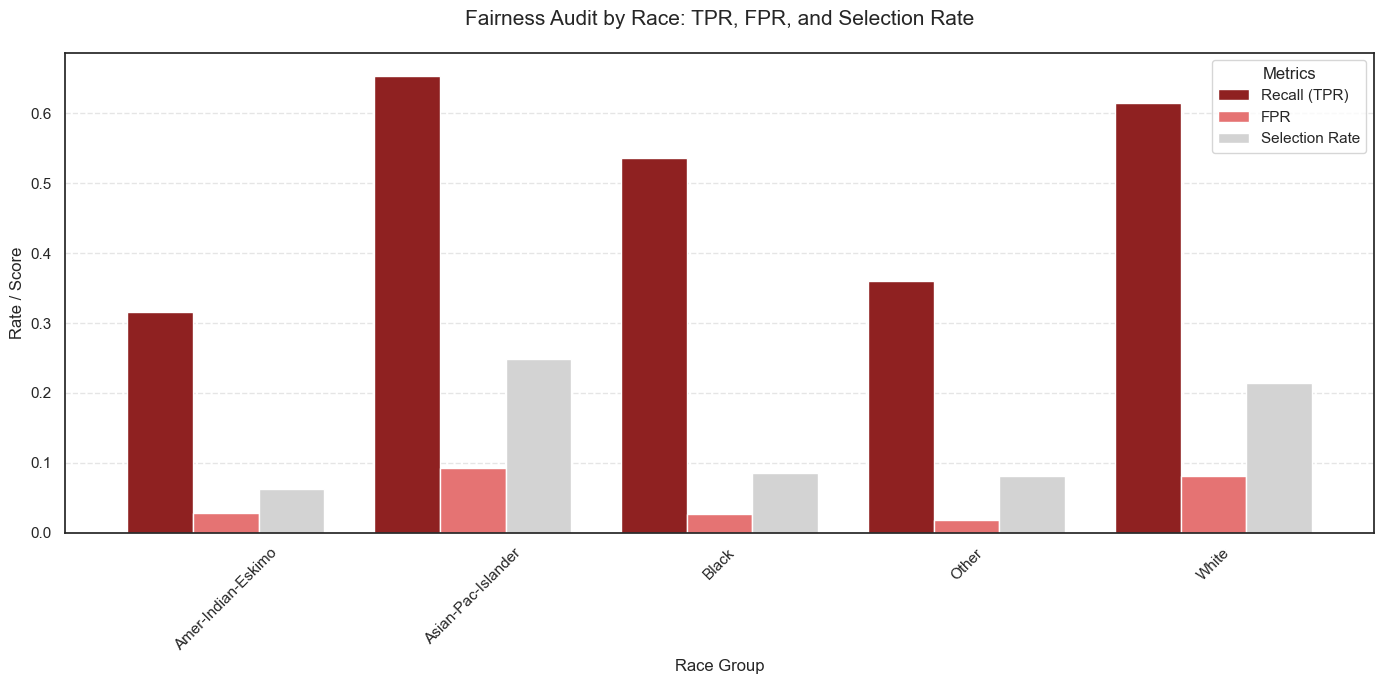

In [246]:

ax_race = metrics_race.by_group[['Recall (TPR)', 'FPR', 'Selection Rate']].plot(
    kind='bar', 
    figsize=(14, 7), 
    color=['#8F2121', '#E57373', '#D3D3D3'],
    width=0.8
)

plt.title('Fairness Audit by Race: TPR, FPR, and Selection Rate', fontsize=15, pad=20)
plt.ylabel('Rate / Score')
plt.xlabel('Race Group')
plt.xticks(rotation=45)
plt.legend(title='Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

______________

Unawareness model (without Sex and Race columns)

In [248]:
metrics_dict = {
        'Accuracy': accuracy_score,
        'Precision': precision_score,
        'Recall (TPR)': recall_score,
        'FPR': false_positive_rate,      
        'F1-Score': f1_score,
        'Selection Rate': selection_rate 
    }

In [250]:
def get_fairness_metrics(y_true, y_pred, sensitive_features):
    """Oblicza poprawne DPD i EOD (jako max różnic TPR i FPR)."""
    # Obliczamy różnice za pomocą MetricFrame
    metrics = {
        'TPR': recall_score,
        'FPR': false_positive_rate,
        'SR': selection_rate
    }
    mf = MetricFrame(metrics=metrics, y_true=y_true, y_pred=y_pred, sensitive_features=sensitive_features)
    diffs = mf.difference(method='between_groups')
    
    return {
        'DPD': diffs['SR'],
        'EOD': max(diffs['TPR'], diffs['FPR'])
    }

def run_unawareness_model(df, target_col='income'):
    train_df = df[df['is_test'] == 0].copy()
    test_df = df[df['is_test'] == 1].copy()

    # Usuwamy sex i race z treningu
    sensitive_cols = ['sex', 'race']
    X_train = train_df.drop(columns=[target_col, 'is_test'] + sensitive_cols)
    X_test = test_df.drop(columns=[target_col, 'is_test'] + sensitive_cols)
    y_train = train_df[target_col]
    y_test = test_df[target_col]

    # Preprocessing & Model (identyczny jak wcześniej)
    numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
    categorical_features = X_train.select_dtypes(include=['category']).columns.tolist()
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features)
    ])

    model = Pipeline([('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)


    f_sex = get_fairness_metrics(y_test, y_pred, test_df['sex'])
    f_race = get_fairness_metrics(y_test, y_pred, test_df['race'])

    return f_sex, f_race


fairness_unaware_sex, fairness_unaware_race = run_unawareness_model(df)

In [ ]:
comparison_sex = pd.DataFrame({
    'Metric': ['DPD (Demographic Parity)', 'EOD (Equalized Odds)'],
    'Baseline': [fairness_sex['DPD'], fairness_sex['EOD']],
    'Unawareness': [fairness_unaware_sex['DPD'], fairness_unaware_sex['EOD']]
})

display(comparison_sex)

--- WPŁYW USUNIĘCIA CECH WRAŻLIWYCH NA PŁEĆ ---


,Metric,Baseline,Unawareness
0,DPD (Demographic Parity),0.174354,0.169744
1,EOD (Equalized Odds),0.076832,0.075269


In [253]:
comparison_race = pd.DataFrame({
    'Metric': ['DPD (Demographic Parity)', 'EOD (Equalized Odds)'],
    'Baseline': [fairness_race['DPD'], fairness_race['EOD']],
    'Unawareness': [fairness_unaware_race['DPD'], fairness_unaware_race['EOD']]
})  
display(comparison_race)

,Metric,Baseline,Unawareness
0,DPD (Demographic Parity),0.185024,0.163194
1,EOD (Equalized Odds),0.338346,0.231579


# General function for experiments

In [261]:
def run_experiment(df, drop_cols=[], sensitive_col='sex', target_col='income'):
    """
    Uniwersalna funkcja do trenowania modelu i wyliczania wszystkich metryk.
    drop_cols: lista kolumn do usunięcia (np. [], ['sex', 'race'], lub ['sex', 'race', 'relationship'])
    """
    train_df = df[df['is_test'] == 0].copy()
    test_df = df[df['is_test'] == 1].copy()

    y_train = train_df[target_col]
    y_test = test_df[target_col]

    # Dynamiczne usuwanie kolumn
    X_train = train_df.drop(columns=[target_col, 'is_test'] + drop_cols)
    X_test = test_df.drop(columns=[target_col, 'is_test'] + drop_cols)

    # Preprocessing (automatyczny wybór cech po drop_cols)
    numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
    categorical_features = X_train.select_dtypes(include=['category']).columns.tolist()

    preprocessor = ColumnTransformer(transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features)
    ])

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # 1. Metryki klasyfikacji (Overall Accuracy)
    acc = accuracy_score(y_test, y_pred)

    # 2. Metryki Fairness dla wybranej kolumny wrażliwej
    # Używamy MetricFrame, żeby wyciągnąć wszystko za jednym razem
    metrics_dict = {
        'TPR': recall_score,
        'FPR': false_positive_rate,
        'SR': selection_rate
    }
    
    mf = MetricFrame(
        metrics=metrics_dict,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=test_df[sensitive_col]
    )
    
    diffs = mf.difference(method='between_groups')
    
    results = {
        'Accuracy': acc,
        'DPD': diffs['SR'],
        'EOD': max(diffs['TPR'], diffs['FPR']),
        'TPR_diff': diffs['TPR'],
        'FPR_diff': diffs['FPR']
    }
    
    return results, mf

In [258]:
# KROK 1: Baseline (nic nie usuwamy)
res_baseline = run_experiment(df, drop_cols=[], sensitive_col='sex')

# KROK 2: Unawareness (usuwamy tylko cechy wrażliwe)
res_unaware = run_experiment(df, drop_cols=['sex', 'race'], sensitive_col='sex')

# KROK 3: No-Proxy (usuwamy cechy wrażliwe + najsilniejsze proxy)
res_no_proxy = run_experiment(df, drop_cols=['sex', 'race', 'relationship', 'marital-status'], sensitive_col='sex')

# Zbieramy wszystko w jedną piękną tabelę
final_comparison = pd.DataFrame({
    'Baseline': res_baseline,
    'Unawareness': res_unaware,
    'No-Proxy': res_no_proxy
}).T

display(final_comparison)

,Accuracy,DPD,EOD,TPR_diff,FPR_diff
Baseline,0.850869,0.174354,0.076832,0.068624,0.076832
Unawareness,0.848781,0.169744,0.075269,0.052005,0.075269
No-Proxy,0.813893,0.097501,0.035900,0.035900,0.018042


# RACE comparison experiments 

- run all

In [262]:
# Definicja kolumn proxy dla rasy
race_proxies = ['native-country', 'relationship', 'marital-status']

# KROK 1: Baseline
res_base, mf_base = run_experiment(df, drop_cols=[], sensitive_col='race')

# KROK 2: Unawareness
res_unaware, mf_unaware = run_experiment(df, drop_cols=['sex', 'race'], sensitive_col='race')

# KROK 3: No-Proxy
res_no_proxy, mf_no_proxy = run_experiment(df, drop_cols=['sex', 'race'] + race_proxies, sensitive_col='race')

# Tabela zbiorcza wyników ogólnych (to co już masz, ale usystematyzowane)
race_overall_comparison = pd.DataFrame({
    'Baseline': res_base,
    'Unawareness': res_unaware,
    'No-Proxy': res_no_proxy
}).T
display(race_overall_comparison)

,Accuracy,DPD,EOD,TPR_diff,FPR_diff
Baseline,0.850869,0.185024,0.338346,0.338346,0.074037
Unawareness,0.848781,0.163194,0.231579,0.231579,0.088446
No-Proxy,0.812849,0.111111,0.108619,0.106229,0.108619


- general comparison

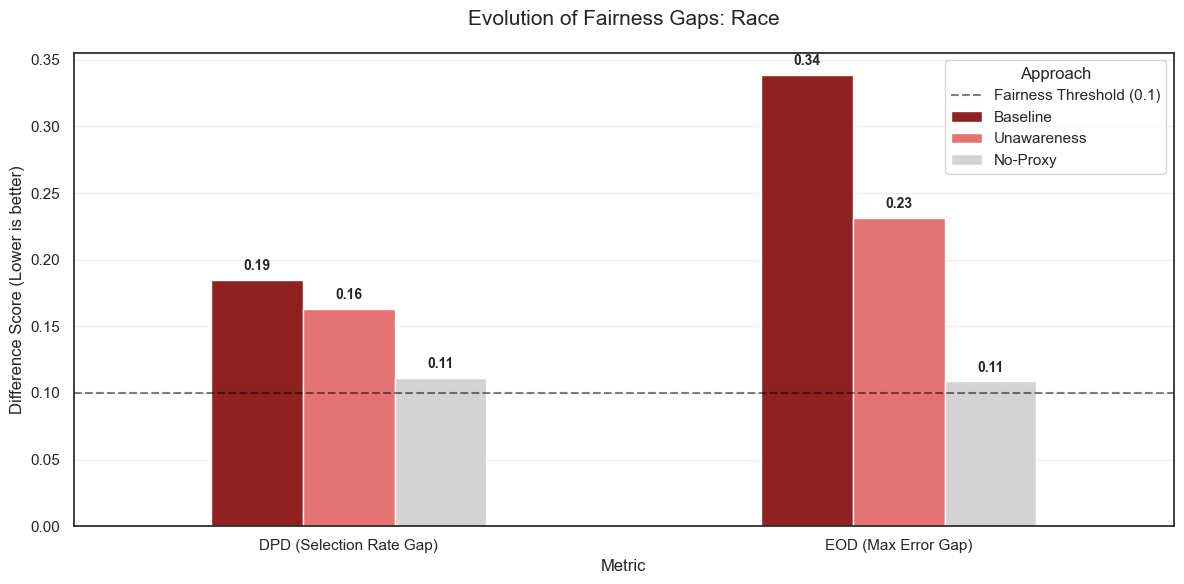

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

race_comparison = pd.DataFrame({
    'Metric': ['DPD (Selection Rate Gap)', 'EOD (Max Error Gap)'],
    'Baseline': [0.185024, 0.338346],
    'Unawareness': [0.163194, 0.231579],
    'No-Proxy': [0.111111, 0.108619]
})

ax = race_comparison.plot(kind='bar', x='Metric', figsize=(12, 6), color=['#8F2121', '#E57373', '#D3D3D3'], rot=0)

plt.title('Evolution of Fairness Gaps: Race', fontsize=15, pad=20)
plt.ylabel('Difference Score (Lower is better)')
plt.axhline(y=0.1, color='black', linestyle='--', alpha=0.5, label='Fairness Threshold (0.1)')
plt.legend(title='Approach')
plt.grid(axis='y', alpha=0.3)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

- Subgroups comparison

In [264]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Przygotowujemy dane z trzech etapów
def prep_data(mf, label):
    df_temp = mf.by_group.reset_index()
    df_temp['Model'] = label
    return df_temp

# Łączymy wyniki (możesz dodać też Unawareness, jeśli chcesz)
comparison_data = pd.concat([
    prep_data(mf_base, 'Baseline'),
    prep_data(mf_no_proxy, 'No-Proxy')
])

# Przekształcamy tabelę, aby metryki były w jednej kolumnie (Melt)
df_plot = comparison_data.melt(id_vars=['race', 'Model'], 
                               value_vars=['TPR', 'FPR', 'SR'], 
                               var_name='Metric', value_name='Value')

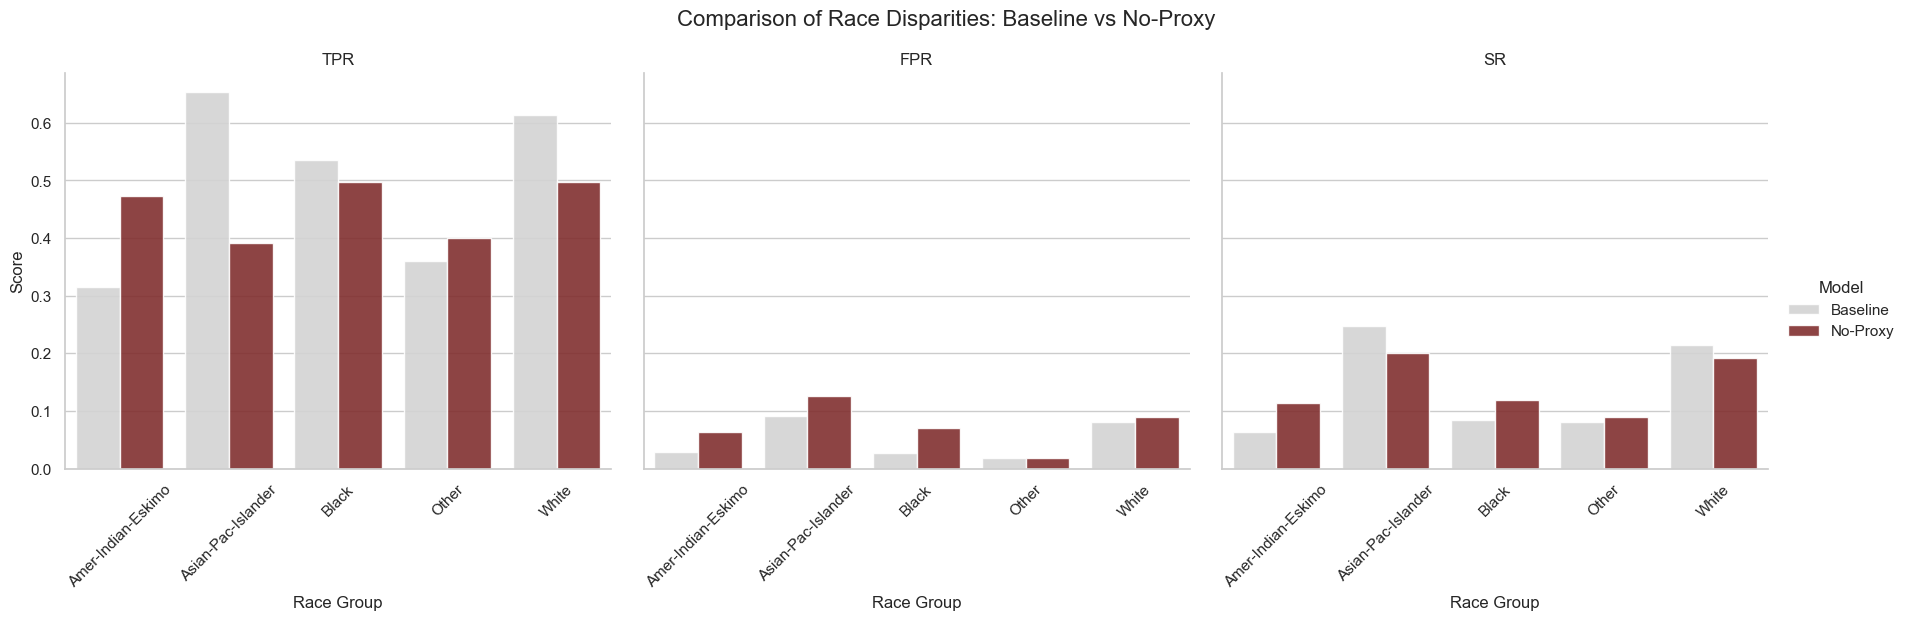

In [265]:
# Ustawienie stylu
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_plot, kind="bar",
    x="race", y="Value", hue="Model",
    col="Metric", # Każda metryka dostaje własny wykres
    palette=['#D3D3D3', '#8F2121'], # Szary dla Baseline, Twój czerwony dla No-Proxy
    alpha=0.9, height=5, aspect=1.2
)

# Poprawa czytelności
g.set_axis_labels("Race Group", "Score")
g.set_titles("{col_name}")
g.set_xticklabels(rotation=45)
g.fig.suptitle('Comparison of Race Disparities: Baseline vs No-Proxy', fontsize=16, y=1.05)

plt.show()

# Gender analysis

- run experiments

In [269]:
# Definicja kolumn proxy dla płci (głównie status relacji i stan cywilny)
sex_proxies = ['relationship', 'marital-status']

# KROK 1: Baseline
res_base_sex, mf_base_sex = run_experiment(df, drop_cols=[], sensitive_col='sex')

# KROK 2: Unawareness
res_unaware_sex, mf_unaware_sex = run_experiment(df, drop_cols=['sex', 'race'], sensitive_col='sex')

# KROK 3: No-Proxy
res_no_proxy_sex, mf_no_proxy_sex = run_experiment(df, drop_cols=['sex', 'race'] + sex_proxies, sensitive_col='sex')

# Tabela zbiorcza wyników ogólnych
sex_overall_comparison = pd.DataFrame({
    'Baseline': res_base_sex,
    'Unawareness': res_unaware_sex,
    'No-Proxy': res_no_proxy_sex
}).T
display(sex_overall_comparison)

,Accuracy,DPD,EOD,TPR_diff,FPR_diff
Baseline,0.850869,0.174354,0.076832,0.068624,0.076832
Unawareness,0.848781,0.169744,0.075269,0.052005,0.075269
No-Proxy,0.813893,0.097501,0.035900,0.035900,0.018042


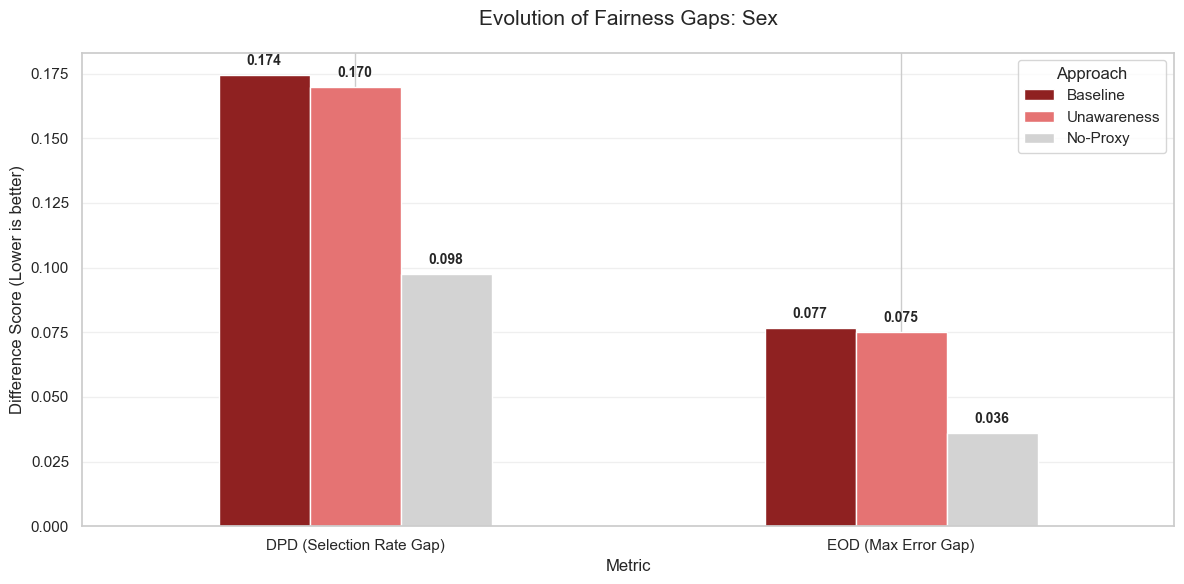

In [271]:
import matplotlib.pyplot as plt
import pandas as pd

# Dane dla Płci na podstawie Twoich wyników
sex_gap_comparison = pd.DataFrame({
    'Metric': ['DPD (Selection Rate Gap)', 'EOD (Max Error Gap)'],
    'Baseline': [res_base_sex['DPD'], res_base_sex['EOD']],
    'Unawareness': [res_unaware_sex['DPD'], res_unaware_sex['EOD']],
    'No-Proxy': [res_no_proxy_sex['DPD'], res_no_proxy_sex['EOD']]
})

ax = sex_gap_comparison.plot(kind='bar', x='Metric', figsize=(12, 6), color=['#8F2121', '#E57373', '#D3D3D3'], rot=0)

plt.title('Evolution of Fairness Gaps: Sex', fontsize=15, pad=20)
plt.ylabel('Difference Score (Lower is better)')
plt.legend(title='Approach')
plt.grid(axis='y', alpha=0.3)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

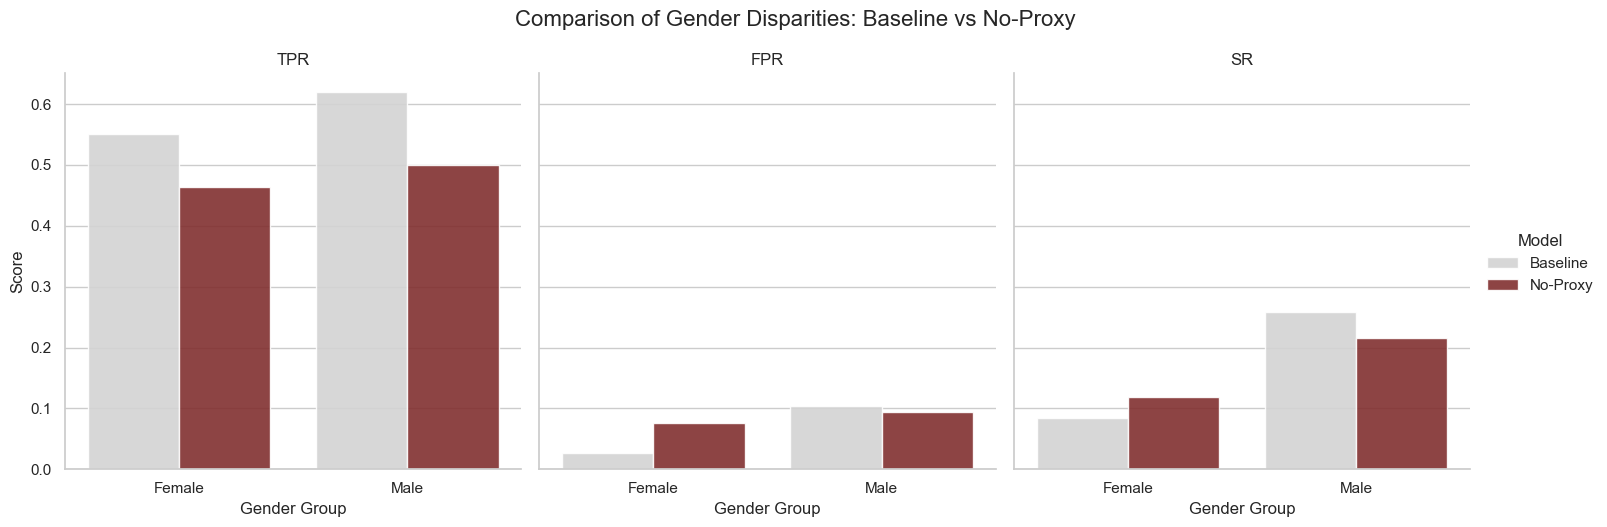

In [272]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Przygotowujemy dane (Baseline vs No-Proxy)
def prep_data_sex(mf, label):
    df_temp = mf.by_group.reset_index()
    df_temp['Model'] = label
    return df_temp

comparison_data_sex = pd.concat([
    prep_data_sex(mf_base_sex, 'Baseline'),
    prep_data_sex(mf_no_proxy_sex, 'No-Proxy')
])

# Melt do formatu long
df_plot_sex = comparison_data_sex.melt(id_vars=['sex', 'Model'], 
                                       value_vars=['TPR', 'FPR', 'SR'], 
                                       var_name='Metric', value_name='Value')

# Ustawienie stylu i wykres panelowy
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_plot_sex, kind="bar",
    x="sex", y="Value", hue="Model",
    col="Metric",
    palette=['#D3D3D3', '#8F2121'],
    alpha=0.9, height=5, aspect=1.0
)

# Poprawa czytelności
g.set_axis_labels("Gender Group", "Score")
g.set_titles("{col_name}")
g.fig.suptitle('Comparison of Gender Disparities: Baseline vs No-Proxy', fontsize=16, y=1.05)

plt.show()

# END 

Wnioseki (pl)
Obie cechy wykazują zbliżony, wysoki poziom braku równości demograficznej.

Analiza metryk wewnątrz podgrup płciowych ujawnia systematyczną stronniczość modelu baseline. Największą dysproporcję widać w Selection Rate (26% dla mężczyzn vs 8% dla kobiet), co wskazuje na wyraźny brak równości demograficznej.

Kluczowym znaleziskiem jest różnica w FPR (False Positive Rate). Model trzykrotnie częściej przypisuje wysokie zarobki mężczyznom, którzy w rzeczywistości zarabiają mało (10%), niż kobietom w analogicznej sytuacji (3%). W połączeniu z niższym współczynnikiem Recall dla kobiet (55% vs 62%), dane sugerują, że model stawia kobietom znacznie wyższą 'poprzeczkę' wejścia do klasy wysokich zarobków, jednocześnie wykazując większy stopień tolerancji na błędy (tzw. kredyt zaufania) wobec grupy mężczyzn

Wysokie DPD (0.17) wynika w dużej mierze z historycznych nierówności obecnych w zbiorze danych (niższy base rate wysokich zarobków u kobiet). Jednak fakt, że model wykazuje niższy Recall (TPR) oraz znacznie niższy FPR dla kobiet niż dla mężczyzn, dowodzi, że algorytm nie tylko odwzorowuje te różnice, ale dodatkowo stawia kobietom surowsze warunki klasyfikacji, co pogłębia istniejącą niesprawiedliwość.

Audyt sprawiedliwości względem rasy ujawnia głębokie nierówności, znacznie wykraczające poza proste różnice w liczebności grup. Wskaźnik EOD (0.33) znajduje odzwierciedlenie w drastycznych różnicach Recall (TPR) – model dwukrotnie rzadziej identyfikuje osoby zamożne w grupach mniejszościowych (Amer-Indian, Other) niż w grupie White czy Asian.

Co więcej, model wykazuje silną stronniczość w zakresie 'kredytu zaufania' (FPR). Osoby o pochodzeniu azjatyckim lub białym mają ok. 3-4 razy większą szansę na optymistyczną pomyłkę modelu niż osoby czarnoskóre czy rdzenni Amerykanie. Sugeruje to, że algorytm baseline utrwala stereotypy rasowe, promując grupy dominujące nie tylko ze względu na ich cechy, ale także poprzez wyższy margines błędu na ich korzyść.


______________________